<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [232]:
from google.colab import files

In [233]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

In [234]:
uploaded = files.upload()

Saving weatherHistory.csv to weatherHistory (1).csv


In [235]:

df = pd.read_csv('weatherHistory.csv')

features = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
    'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
    'Pressure (millibars)'
]
X = df[features].copy()

In [236]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


In [237]:
eps = 0.5
min_samples = 14

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters = dbscan.fit_predict(X_scaled)

In [238]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

In [239]:

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_outliers = np.sum(clusters == -1)
outlier_percentage = n_outliers / len(df_pca) * 100

In [240]:
print(f"DBSCAN Parameters: epsilon={eps}, min_samples={min_samples}")
print(f"Number of clusters found: {n_clusters}")
print(f"Number of outliers found (cluster -1): {n_outliers}")
print(f"Outlier percentage: {outlier_percentage:.2f}%")

DBSCAN Parameters: epsilon=0.5, min_samples=14
Number of clusters found: 9
Number of outliers found (cluster -1): 4567
Outlier percentage: 4.73%


In [241]:
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

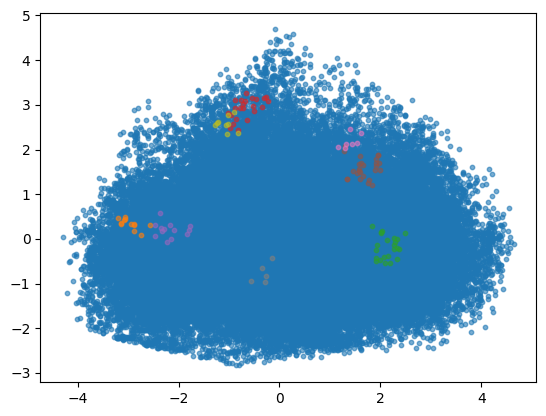

In [242]:
cluster_artists = []
for cluster_id in sorted(df_pca['Cluster'].unique()):
    if cluster_id != -1:
        subset = df_pca[df_pca['Cluster'] == cluster_id]
        artist = plt.scatter(subset['PC1'], subset['PC2'],
                             label=f'Cluster {cluster_id}', s=10, alpha=0.6)
        cluster_artists.append(artist)

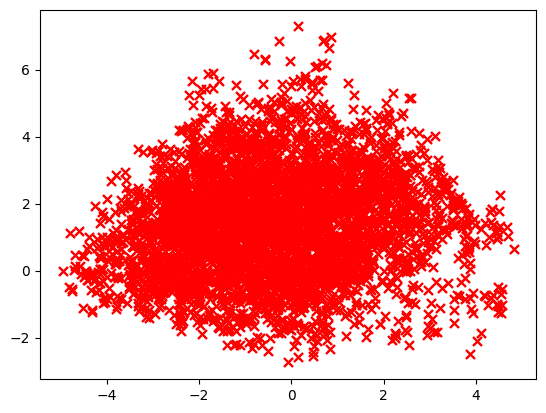

In [243]:
outliers = df_pca[df_pca['Cluster'] == -1]
plt.scatter(outliers['PC1'], outliers['PC2'],
            label='Outliers (-1)', color='red', s=40, marker='x', alpha=1.0)
outlier_artist = plt.scatter(outliers['PC1'], outliers['PC2'],
                             label='Outliers (-1)', color='red', s=40, marker='x', alpha=1.0)

Corrected Plot saved as dbscan_outliers_corrected.png


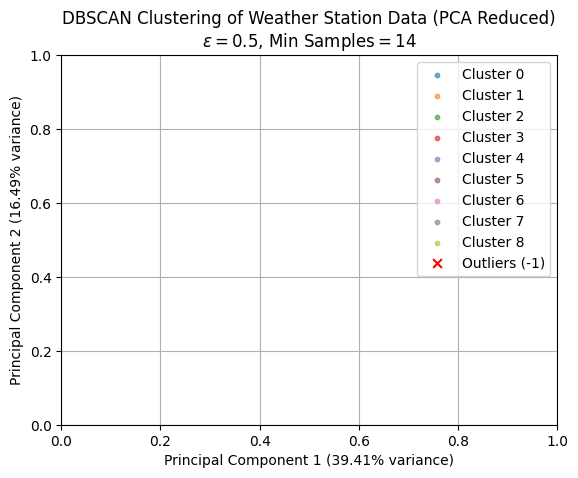

In [244]:
explained_var_pc1 = pca.explained_variance_ratio_[0] * 100
explained_var_pc2 = pca.explained_variance_ratio_[1] * 100
plt.title(f'DBSCAN Clustering of Weather Station Data (PCA Reduced)\n$\\epsilon={eps}$, $\\text{{Min Samples}}={min_samples}$')
plt.xlabel(f'Principal Component 1 ({explained_var_pc1:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_var_pc2:.2f}% variance)')
plt.legend(handles=[*cluster_artists, outlier_artist], loc='best')

plt.grid(True)
plt.savefig('dbscan_outliers_corrected.png')
print("Corrected Plot saved as dbscan_outliers_corrected.png")